# 03 LSTM Model
Build and evaluate an LSTM classifier for short-term ETH drawdown prediction.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/antoniabulai/Documents/GitHub/ML-Project-2026/data/processed/eth_merged_6h_2021_to_latest.csv")
df["hour"] = pd.to_datetime(df["hour"])

1) *ETH Price + Whale Activity (Dual Axis Plot)*

This shows price vs whale activity at the same time.

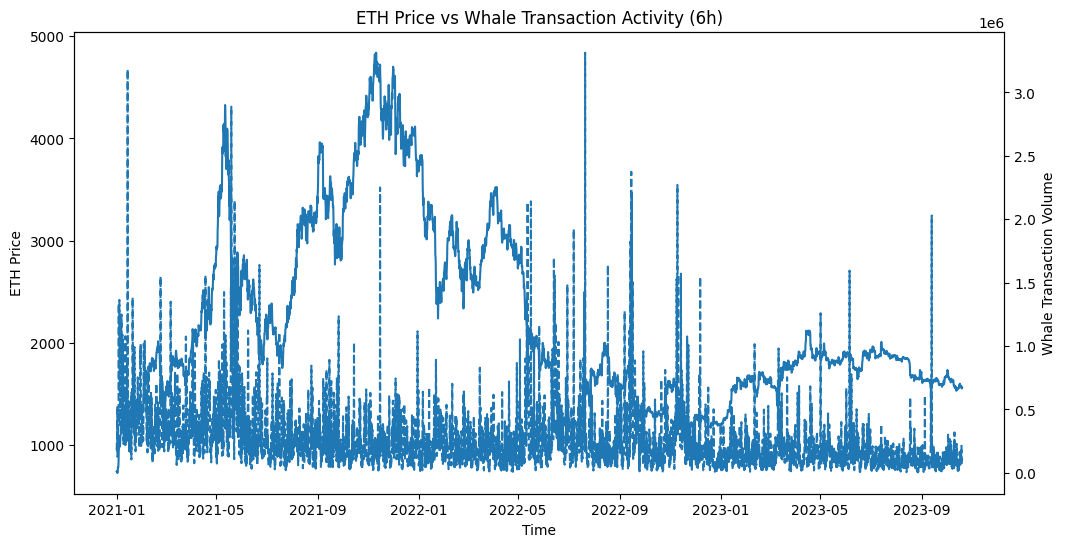

In [ ]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(df["hour"], df["Close"], label="ETH Price")
ax1.set_xlabel("Time")
ax1.set_ylabel("ETH Price")

ax2 = ax1.twinx()
ax2.plot(df["hour"], df["massive_whale_volume"], linestyle="--")
ax2.set_ylabel("Whale Transaction Volume")

plt.title("ETH Price vs Whale Transaction Activity (6h)")
plt.show()

2) *Drawdown Events + Whale Activity*

This highlights when (drawdown_6h_label) triggers. So, it can help answer: Do whale transactions increase before price drops?

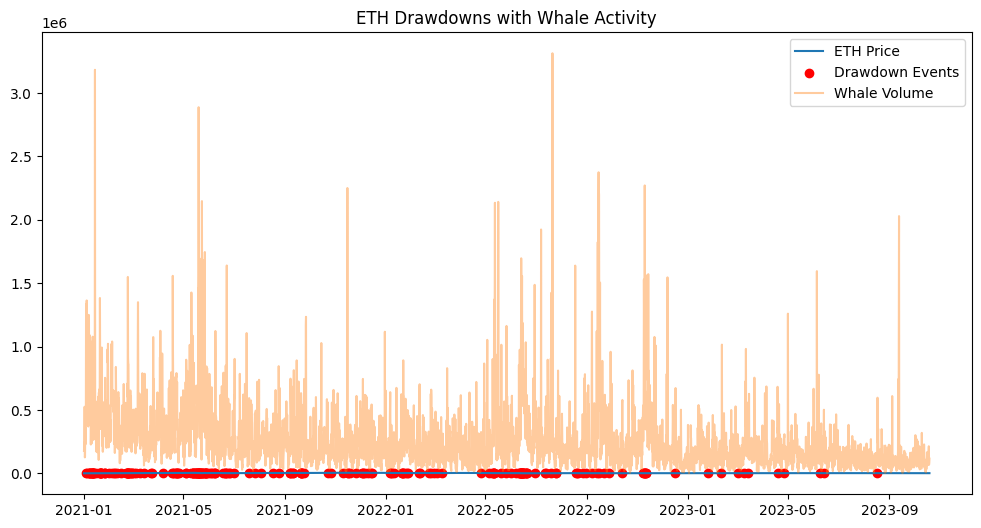

In [8]:
drawdowns = df[df["drawdown_6h_label"] == 1]

plt.figure(figsize=(12,6))

plt.plot(df["hour"], df["Close"], label="ETH Price")

plt.scatter(
    drawdowns["hour"],
    drawdowns["Close"],
    color="red",
    label="Drawdown Events"
)

plt.plot(df["hour"], df["massive_whale_volume"], alpha=0.4, label="Whale Volume")

plt.title("ETH Drawdowns with Whale Activity")
plt.legend()
plt.show()

3) *Correlation Heatmap (Price + Whale Features)*

This shows: which whale metrics correlate with price, which correlate with drawdown label


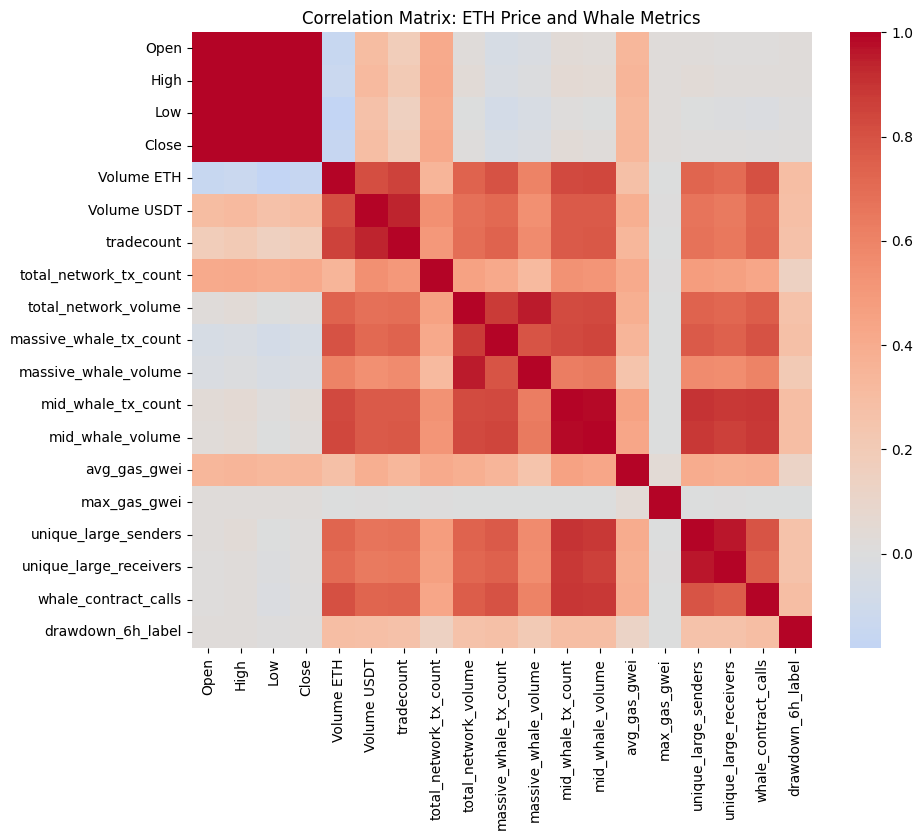

In [10]:
import seaborn as sns

numeric_df = df.select_dtypes(include=["float64", "int64"])

corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Correlation Matrix: ETH Price and Whale Metrics")
plt.show()